<a href="https://colab.research.google.com/github/prakashsurywanshi/quantum-safe-residential-iot/blob/main/Copy%20of%20A%20Sustainable%20Hybrid%20QKD%E2%80%93PQC%20Security%20Architecture%20for%20Quantum-Resilient%20Residential%20IoT%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== EXPERIMENTAL ENERGY CONSUMPTION (mJ) ===
 Scale (N)  Classical (mJ)  PQC-Only (mJ)  QKD-Assisted (mJ)  Hybrid QHSG (Proposed) (mJ)
        10           22.36          50.06             1.3856                      47.2744
        25           55.90         125.15             3.4640                     118.1860
        50          111.80         250.30             6.9280                     236.3720
       100          223.60         500.60            13.8560                     472.7440
       250          559.00        1251.50            34.6400                    1181.8600
       500         1118.00        2503.00            69.2800                    2363.7200


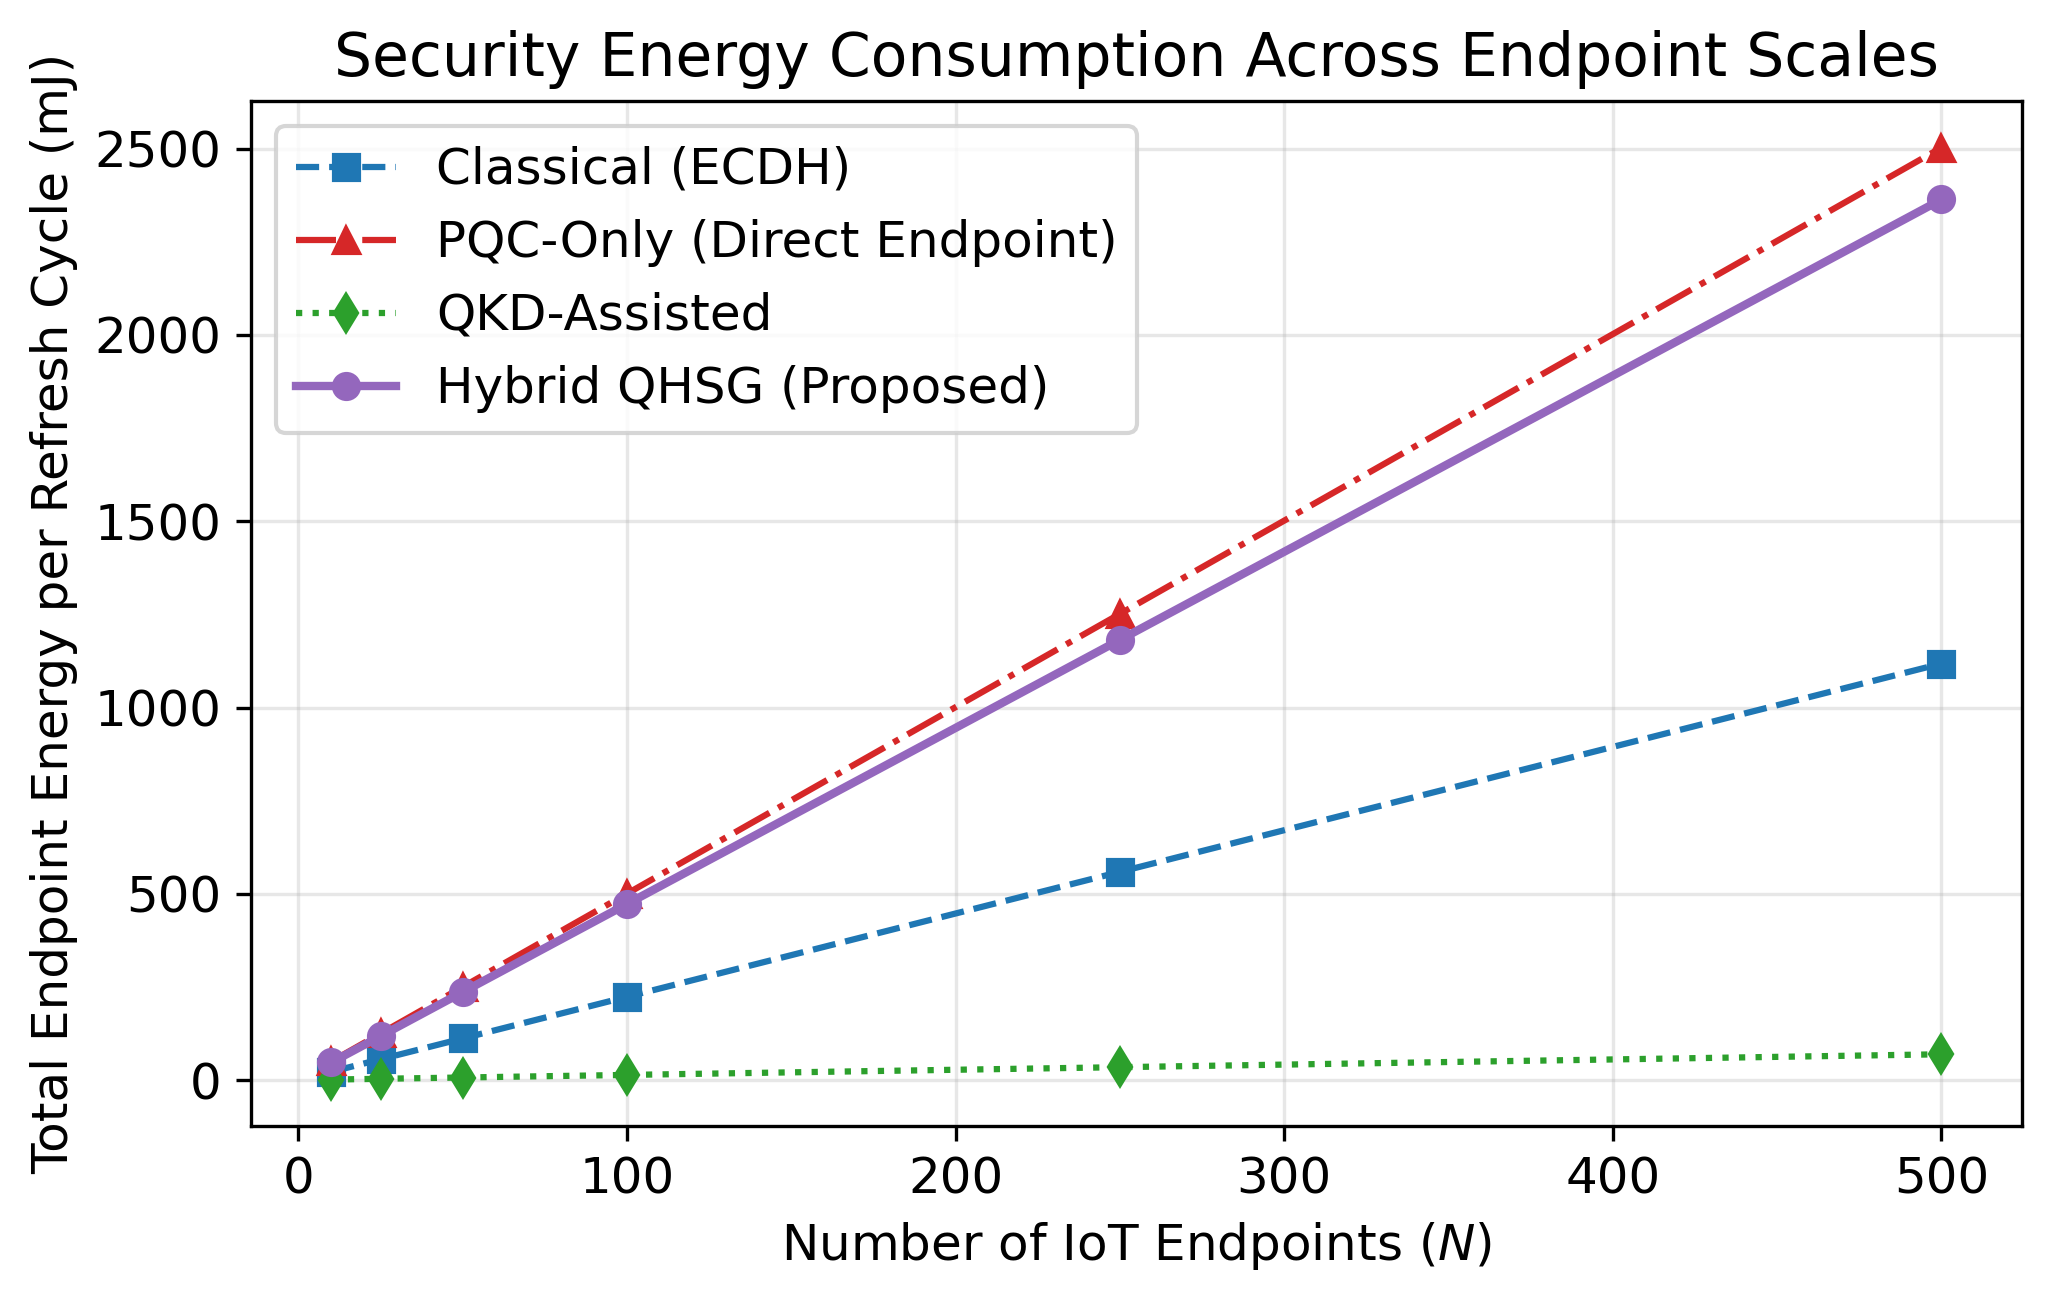

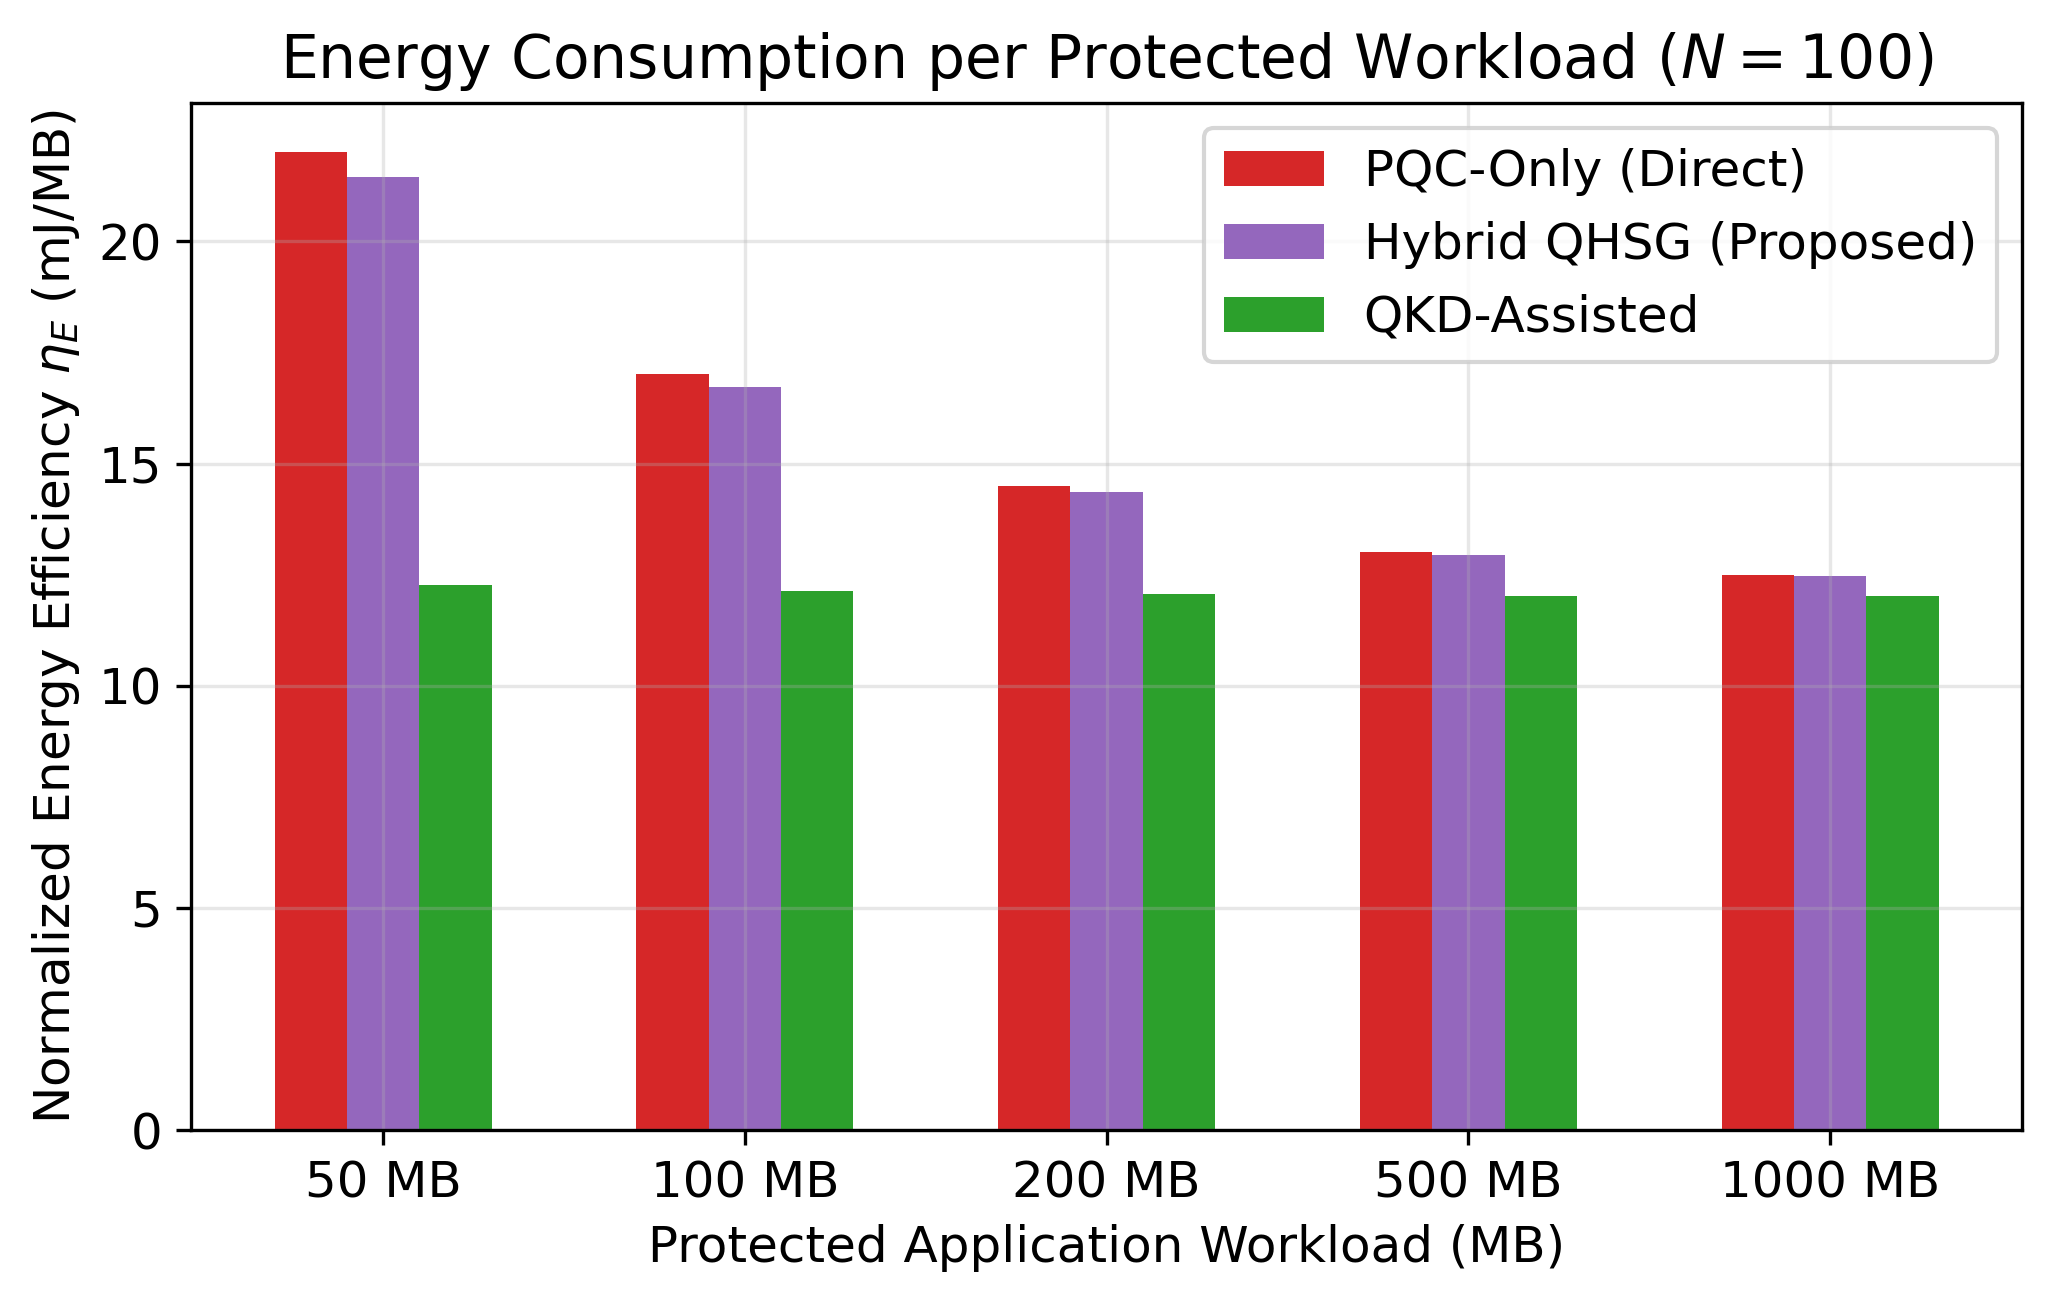

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set visual style suitable for Elsevier IEEE/SCI figures
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'figure.autolayout': True,
    'axes.grid': True,
    'grid.alpha': 0.3
})

# ==========================================
# 1. PARAMETERS & BENCHMARK ASSUMPTIONS
# ==========================================
# Baseline energy and execution profile for ARM Cortex-M4 / ESP32 class devices:
# P_cpu ~ 132 mW (3.3V * 40mA), P_tx ~ 250 mW (Wi-Fi/BLE transmission)
P_CPU_W = 0.132
P_TX_W = 0.250

# Cryptographic execution time per handshake/key-gen (seconds)
T_EXEC = {
    'Classical (ECDH)': 0.015,       # 15 ms
    'PQC (ML-KEM-768)': 0.0035,     # 3.5 ms (lattice ops are computationally fast)
    'QKD-Assisted': 0.0008,          # Buffer read + nonce derivation
    'Hybrid (QHSG)': 0.0042          # HKDF combine (K_q || K_p)
}

# Key establishment communication payload (Bytes transmitted)
# Public keys, ciphertexts, signatures:
COMM_BYTES = {
    'Classical (ECDH)': 64 + 64,      # 128 B
    'PQC (ML-KEM-768)': 1184 + 1088,  # 2272 B (ML-KEM pubkey + ciphertext)
    'QKD-Assisted': 64,               # Key ID sync only
    'Hybrid (QHSG)': 2272 + 64        # PQC key exchange + QKD key-index
}

# Bitrate assumption: 1 Mbps for constrained IoT control channel
BITRATE = 1e6

def calc_energy_per_handshake(scheme, is_gateway_mediated=False):
    t_comp = T_EXEC[scheme]
    t_comm = (COMM_BYTES[scheme] * 8) / BITRATE

    # In QHSG architecture, endpoint only executes lightweight symmetric operations
    if is_gateway_mediated:
        # Endpoint energy reduced to simple symmetric payload encryption/decryption
        e_comp = (t_comp * 0.1) * P_CPU_W
        e_comm = t_comm * P_TX_W
    else:
        e_comp = t_comp * P_CPU_W
        e_comm = t_comm * P_TX_W

    return (e_comp + e_comm) * 1000  # Return in milliJoules (mJ)

# ==========================================
# 2. RUN SIMULATION ACROSS DEVICE SCALES (N)
# ==========================================
device_scales = [10, 25, 50, 100, 250, 500]

results = {
    'Scale (N)': device_scales,
    'Classical (mJ)': [],
    'PQC-Only (mJ)': [],
    'QKD-Assisted (mJ)': [],
    'Hybrid QHSG (Proposed) (mJ)': []
}

for n in device_scales:
    # Aggregated endpoint energy per session key refresh cycle across N devices
    e_classical = n * calc_energy_per_handshake('Classical (ECDH)', is_gateway_mediated=False)
    e_pqc = n * calc_energy_per_handshake('PQC (ML-KEM-768)', is_gateway_mediated=False)
    e_qkd = n * calc_energy_per_handshake('QKD-Assisted', is_gateway_mediated=True)
    e_hybrid = n * calc_energy_per_handshake('Hybrid (QHSG)', is_gateway_mediated=True)

    results['Classical (mJ)'].append(e_classical)
    results['PQC-Only (mJ)'].append(e_pqc)
    results['QKD-Assisted (mJ)'].append(e_qkd)
    results['Hybrid QHSG (Proposed) (mJ)'].append(e_hybrid)

df = pd.DataFrame(results)
print("=== EXPERIMENTAL ENERGY CONSUMPTION (mJ) ===")
print(df.to_string(index=False))

# ==========================================
# 3. GENERATE PUBLICATION-READY FIGURES
# ==========================================
# Figure 1: Energy vs Scalability
plt.figure(figsize=(7, 4.5), dpi=300)
plt.plot(df['Scale (N)'], df['Classical (mJ)'], 's--', label='Classical (ECDH)', color='#1f77b4', linewidth=1.5)
plt.plot(df['Scale (N)'], df['PQC-Only (mJ)'], '^-.', label='PQC-Only (Direct Endpoint)', color='#d62728', linewidth=1.5)
plt.plot(df['Scale (N)'], df['QKD-Assisted (mJ)'], 'd:', label='QKD-Assisted', color='#2ca02c', linewidth=1.5)
plt.plot(df['Scale (N)'], df['Hybrid QHSG (Proposed) (mJ)'], 'o-', label='Hybrid QHSG (Proposed)', color='#9467bd', linewidth=2)

plt.xlabel('Number of IoT Endpoints ($N$)')
plt.ylabel('Total Endpoint Energy per Refresh Cycle (mJ)')
plt.title('Security Energy Consumption Across Endpoint Scales')
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig('Fig_Energy_Scalability.png', dpi=300)
plt.savefig('Fig_Energy_Scalability.pdf')
plt.show()

# Figure 2: Energy per Protected Data Unit (Joules / MB)
workload_mb = np.array([50, 100, 200, 500, 1000]) # MB transmitted
# Baseline symmetric streaming energy: ~ 0.012 mJ/KB -> 12 mJ/MB
base_stream_mj = workload_mb * 12.0

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)
bar_width = 0.2
x = np.arange(len(workload_mb))

eta_pqc = (base_stream_mj + results['PQC-Only (mJ)'][3]) / workload_mb
eta_hybrid = (base_stream_mj + results['Hybrid QHSG (Proposed) (mJ)'][3]) / workload_mb
eta_qkd = (base_stream_mj + results['QKD-Assisted (mJ)'][3]) / workload_mb

ax.bar(x - bar_width, eta_pqc, width=bar_width, label='PQC-Only (Direct)', color='#d62728')
ax.bar(x, eta_hybrid, width=bar_width, label='Hybrid QHSG (Proposed)', color='#9467bd')
ax.bar(x + bar_width, eta_qkd, width=bar_width, label='QKD-Assisted', color='#2ca02c')

ax.set_xlabel('Protected Application Workload (MB)')
ax.set_ylabel(r'Normalized Energy Efficiency $\eta_E$ (mJ/MB)')
ax.set_xticks(x)
ax.set_xticklabels([f'{w} MB' for w in workload_mb])
ax.legend(frameon=True)
plt.title(r'Energy Consumption per Protected Workload ($N=100$)')
plt.tight_layout()
plt.savefig('Fig_Energy_Per_MB.png', dpi=300)
plt.savefig('Fig_Energy_Per_MB.pdf')
plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Try importing Google Colab file downloader (works automatically in Colab)
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ==========================================
# 0. PUBLICATION STYLE CONFIGURATION
# ==========================================
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.autolayout': True,
    'axes.grid': True,
    'grid.alpha': 0.3
})

output_dir = "paper_outputs"
os.makedirs(output_dir, exist_ok=True)

# ==========================================
# 1. PARAMETERS & BENCHMARKS
# ==========================================
P_CPU_W = 0.132      # ARM Cortex-M4 (3.3V * 40mA)
P_TX_W = 0.250       # Low-power transceiver (250 mW)
BITRATE = 1e6        # 1 Mbps control channel

T_EXEC = {
    'Classical (ECDH)': 0.015,
    'PQC (ML-KEM-768)': 0.0035,
    'QKD-Assisted': 0.0008,
    'Hybrid (QHSG)': 0.0042
}

COMM_BYTES = {
    'Classical (ECDH)': 128,
    'PQC (ML-KEM-768)': 2272,
    'QKD-Assisted': 64,
    'Hybrid (QHSG)': 2336
}

def calc_energy(scheme, is_gateway_mediated=False):
    t_comp = T_EXEC[scheme]
    t_comm = (COMM_BYTES[scheme] * 8) / BITRATE
    if is_gateway_mediated:
        e_comp = (t_comp * 0.1) * P_CPU_W
    else:
        e_comp = t_comp * P_CPU_W
    e_comm = t_comm * P_TX_W
    return (e_comp + e_comm) * 1000  # Return in mJ

# ==========================================
# 2. RUN EXPERIMENT ACROSS SCALES
# ==========================================
device_scales = [10, 25, 50, 100, 250, 500]

results = {
    'Scale_N': device_scales,
    'Classical_mJ': [n * calc_energy('Classical (ECDH)', False) for n in device_scales],
    'PQC_Only_mJ': [n * calc_energy('PQC (ML-KEM-768)', False) for n in device_scales],
    'QKD_Assisted_mJ': [n * calc_energy('QKD-Assisted', True) for n in device_scales],
    'Hybrid_QHSG_mJ': [n * calc_energy('Hybrid (QHSG)', True) for n in device_scales]
}

df_results = pd.DataFrame(results)

# Export Data Table to CSV
csv_path = os.path.join(output_dir, "Table_Energy_Results.csv")
df_results.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

# ==========================================
# 3. FIGURE 1: SCALABILITY PLOT
# ==========================================
plt.figure(figsize=(6.5, 4.0), dpi=300)
plt.plot(df_results['Scale_N'], df_results['Classical_mJ'], 's--', label='Classical (ECDH)', color='#1f77b4', linewidth=1.5)
plt.plot(df_results['Scale_N'], df_results['PQC_Only_mJ'], '^-.', label='PQC-Only (ML-KEM-768)', color='#d62728', linewidth=1.5)
plt.plot(df_results['Scale_N'], df_results['QKD_Assisted_mJ'], 'd:', label='QKD-Assisted', color='#2ca02c', linewidth=1.5)
plt.plot(df_results['Scale_N'], df_results['Hybrid_QHSG_mJ'], 'o-', label='Hybrid QHSG (Proposed)', color='#9467bd', linewidth=1.8)

plt.xlabel('Number of IoT Endpoints ($N$)')
plt.ylabel('Endpoint Refresh Energy (mJ)')
plt.title('Endpoint Security Energy Overhead across Fleet Scales')
plt.legend(frameon=True)
plt.tight_layout()

# Save PNG and Vector PDF
f1_png = os.path.join(output_dir, "Fig_Energy_Scalability.png")
f1_pdf = os.path.join(output_dir, "Fig_Energy_Scalability.pdf")
plt.savefig(f1_png, dpi=300)
plt.savefig(f1_pdf)
plt.close()
print(f"Saved: {f1_png} and {f1_pdf}")

# ==========================================
# 4. FIGURE 2: WORKLOAD EFFICIENCY (BAR)
# ==========================================
workload_mb = np.array([50, 100, 200, 500, 1000])
base_stream_mj = workload_mb * 12.0  # 12 mJ/MB baseline symmetric streaming

n100_idx = device_scales.index(100)
eta_pqc = (base_stream_mj + results['PQC_Only_mJ'][n100_idx]) / workload_mb
eta_hybrid = (base_stream_mj + results['Hybrid_QHSG_mJ'][n100_idx]) / workload_mb
eta_qkd = (base_stream_mj + results['QKD_Assisted_mJ'][n100_idx]) / workload_mb

fig, ax = plt.subplots(figsize=(6.5, 4.0), dpi=300)
bar_width = 0.25
x = np.arange(len(workload_mb))

ax.bar(x - bar_width, eta_pqc, width=bar_width, label='PQC-Only (Direct)', color='#d62728')
ax.bar(x, eta_hybrid, width=bar_width, label='Hybrid QHSG (Proposed)', color='#9467bd')
ax.bar(x + bar_width, eta_qkd, width=bar_width, label='QKD-Assisted', color='#2ca02c')

ax.set_xlabel('Application Payload Volume (MB)')
ax.set_ylabel(r'Normalized Energy Efficiency $\eta_E$ (mJ/MB)')
ax.set_xticks(x)
ax.set_xticklabels([f'{w} MB' for w in workload_mb])
ax.legend(frameon=True)
plt.title(r'Workload-Normalized Energy Consumption ($N=100$)')
plt.tight_layout()

# Save PNG and Vector PDF
f2_png = os.path.join(output_dir, "Fig_Energy_Per_MB.png")
f2_pdf = os.path.join(output_dir, "Fig_Energy_Per_MB.pdf")
plt.savefig(f2_png, dpi=300)
plt.savefig(f2_pdf)
plt.close()
print(f"Saved: {f2_png} and {f2_pdf}")

# ==========================================
# 5. AUTOMATIC COLAB DOWNLOAD
# ==========================================
if IN_COLAB:
    print("\nInitiating downloads to your local machine...")
    files.download(f1_png)
    files.download(f1_pdf)
    files.download(f2_png)
    files.download(f2_pdf)
    files.download(csv_path)

Saved: paper_outputs/Table_Energy_Results.csv
Saved: paper_outputs/Fig_Energy_Scalability.png and paper_outputs/Fig_Energy_Scalability.pdf
Saved: paper_outputs/Fig_Energy_Per_MB.png and paper_outputs/Fig_Energy_Per_MB.pdf

Initiating downloads to your local machine...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully generated Fig1.png (300 DPI) and Fig1.pdf (Vector) for Overleaf!


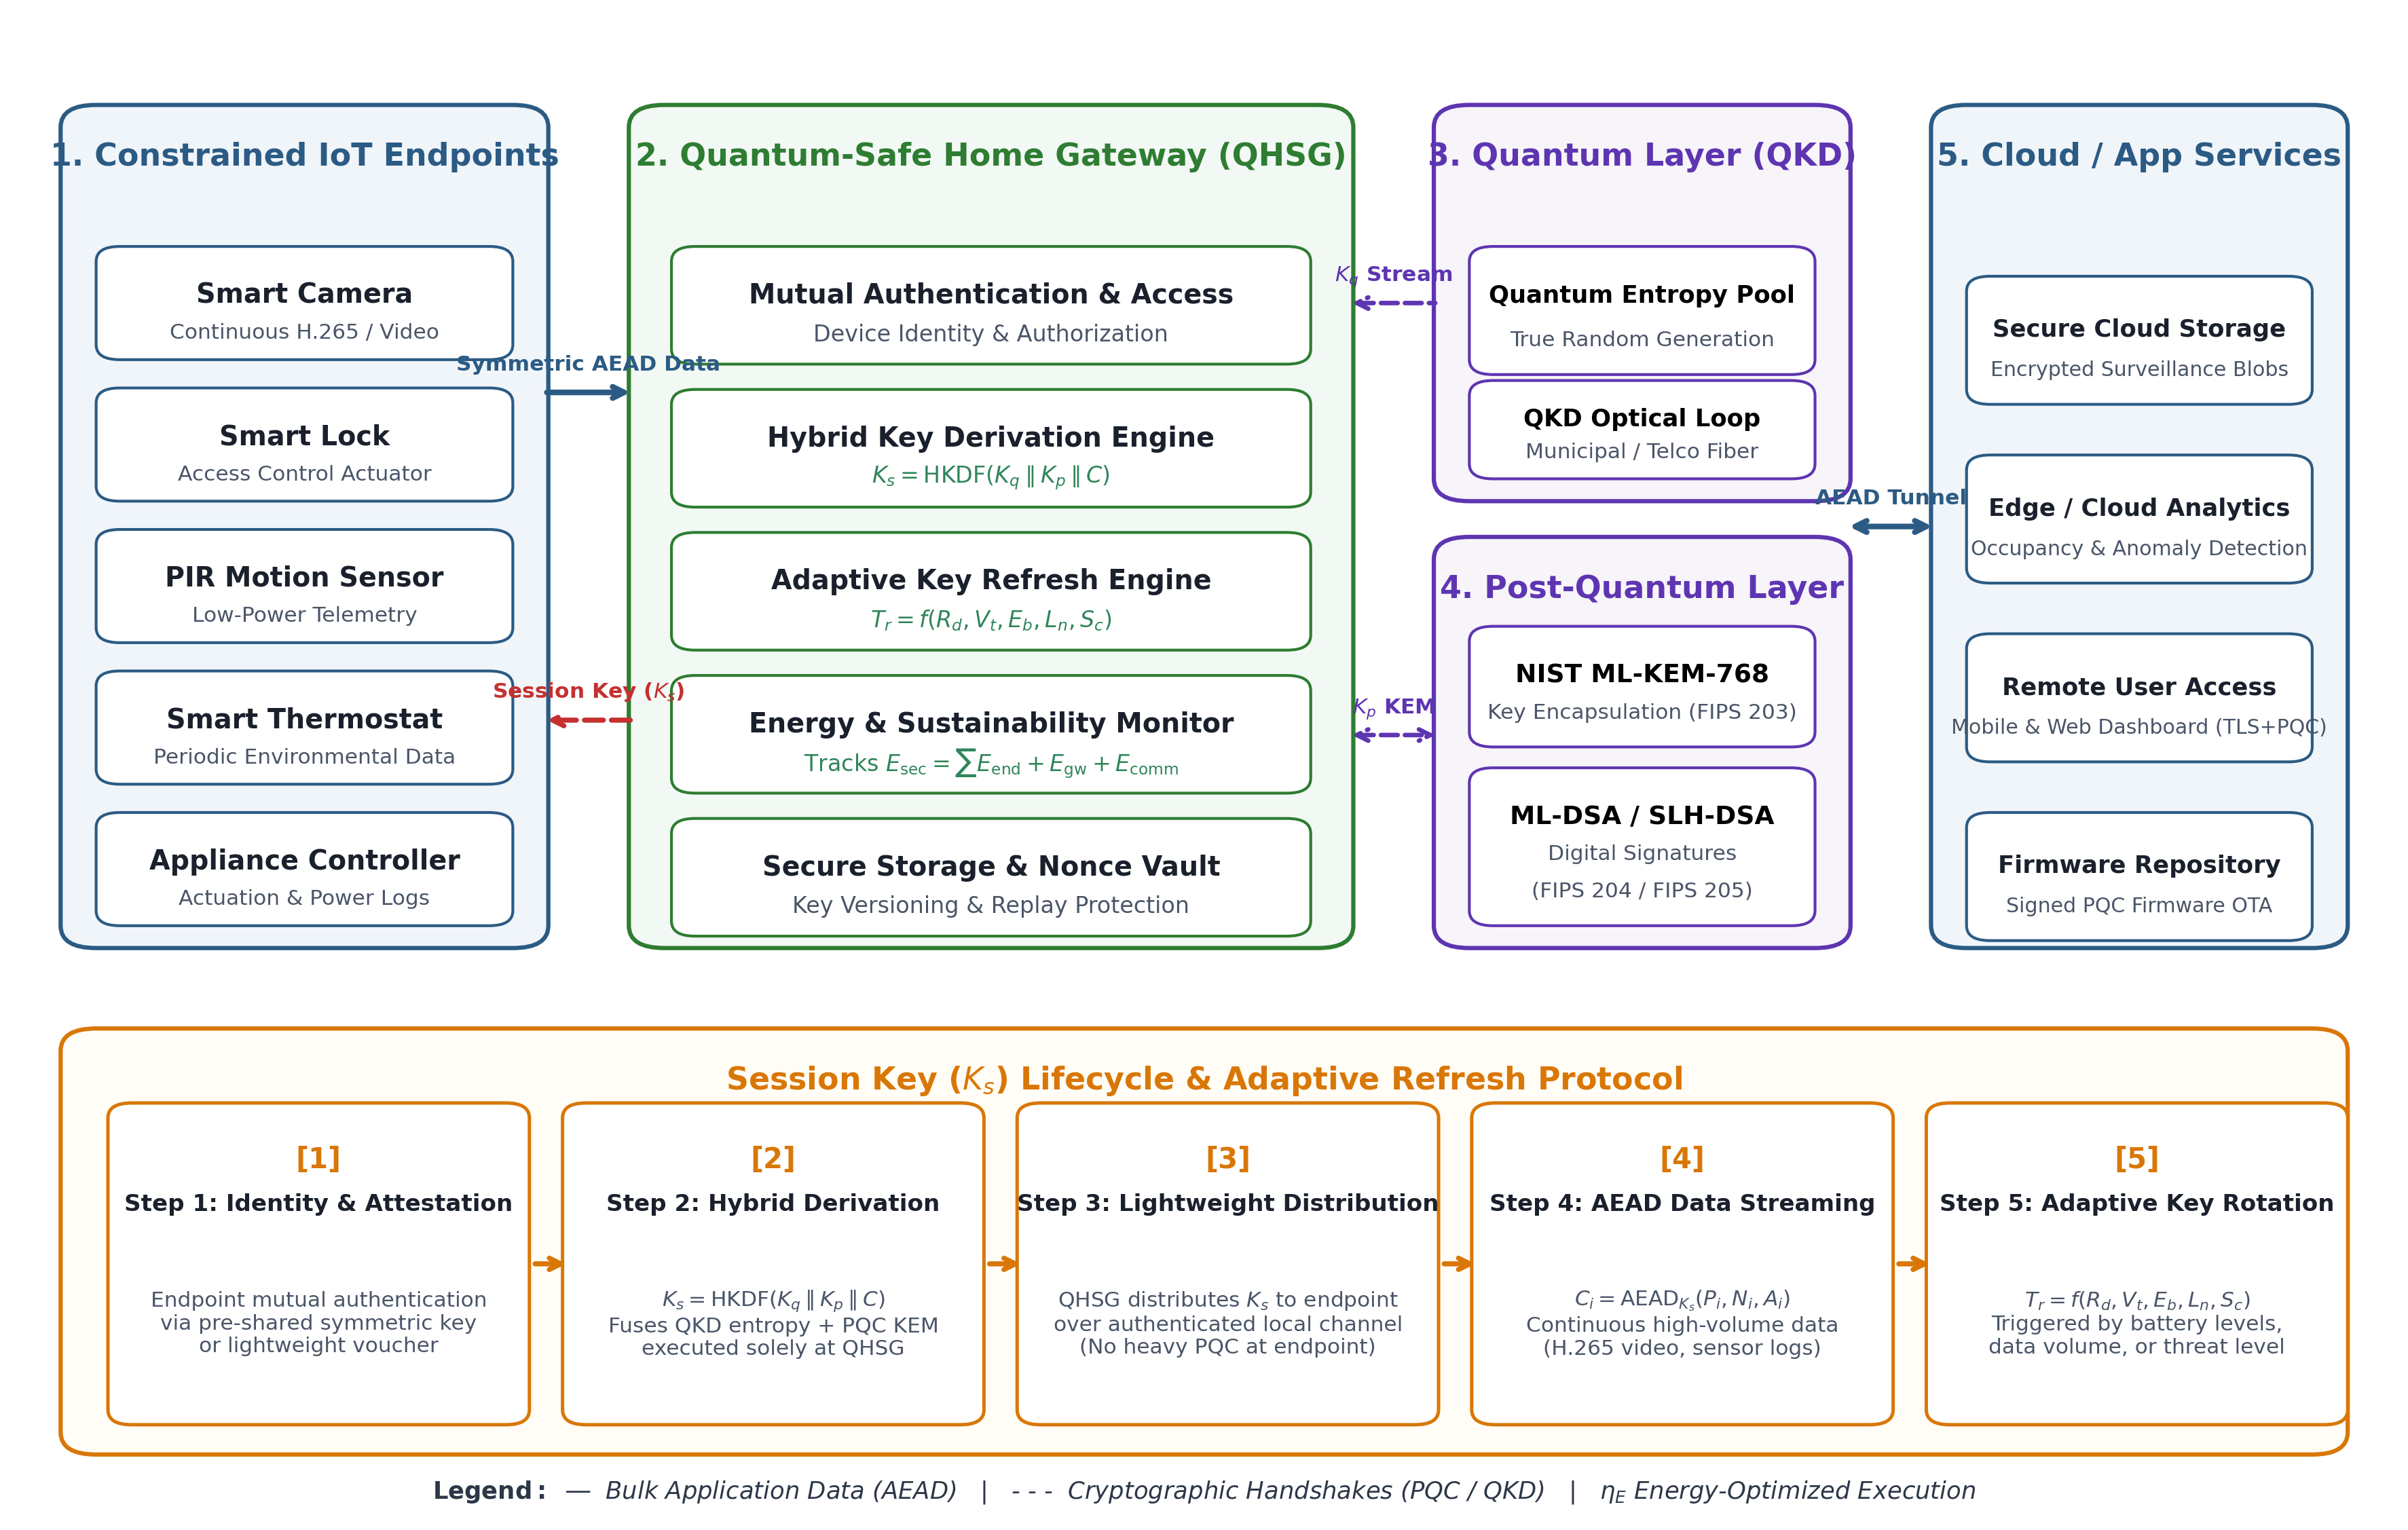

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Publication styling
fig, ax = plt.subplots(figsize=(15, 9.5), dpi=300)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.axis('off')

# Color Palette (Elsevier academic theme)
c_bg_blue   = '#F0F5FA'
c_edge_blue = '#2B5B84'
c_bg_green  = '#F2F8F4'
c_edge_green= '#2E7D32'
c_bg_purp   = '#F7F4FA'
c_edge_purp = '#5E35B1'
c_bg_amber  = '#FFFDF5'
c_edge_amber= '#D97706'
c_box_inner = '#FFFFFF'
c_text_dark = '#1A202C'

def draw_box(x, y, w, h, bg, border, title="", r=1.5, lw=1.5, ls='-'):
    rect = patches.FancyBboxPatch((x, y), w, h, boxstyle=f"round,pad=0.3,rounding_size={r}",
                                  facecolor=bg, edgecolor=border, linewidth=lw, linestyle=ls)
    ax.add_patch(rect)
    if title:
        ax.text(x + w/2, y + h - 3.2, title, ha='center', va='center',
                fontsize=11, fontweight='bold', color=border)

# -------------------------------------------------------------
# 1. IoT DEVICES DOMAIN
# -------------------------------------------------------------
draw_box(2, 38, 20, 56, c_bg_blue, c_edge_blue, "1. Constrained IoT Endpoints")
devices = [
    ("Smart Camera", "Continuous H.265 / Video"),
    ("Smart Lock", "Access Control Actuator"),
    ("PIR Motion Sensor", "Low-Power Telemetry"),
    ("Smart Thermostat", "Periodic Environmental Data"),
    ("Appliance Controller", "Actuation & Power Logs")
]
y_dev = 84
for name, desc in devices:
    draw_box(3.5, y_dev - 6.5, 17, 7, c_box_inner, c_edge_blue, r=1, lw=1)
    ax.text(12, y_dev - 2.5, name, ha='center', va='center', fontsize=9.5, fontweight='bold', color=c_text_dark)
    ax.text(12, y_dev - 5.0, desc, ha='center', va='center', fontsize=7.5, color='#4A5568')
    y_dev -= 9.5

# -------------------------------------------------------------
# 2. QUANTUM-SAFE GATEWAY (QHSG)
# -------------------------------------------------------------
draw_box(26, 38, 30, 56, c_bg_green, c_edge_green, "2. Quantum-Safe Home Gateway (QHSG)")

gw_modules = [
    ("Mutual Authentication & Access", "Device Identity & Authorization"),
    ("Hybrid Key Derivation Engine", r"$K_s = \mathrm{HKDF}(K_q \parallel K_p \parallel C)$"),
    ("Adaptive Key Refresh Engine", r"$T_r = f(R_d, V_t, E_b, L_n, S_c)$"),
    ("Energy & Sustainability Monitor", r"Tracks $E_{\mathrm{sec}} = \sum E_{\mathrm{end}} + E_{\mathrm{gw}} + E_{\mathrm{comm}}$"),
    ("Secure Storage & Nonce Vault", "Key Versioning & Replay Protection")
]
y_gw = 84
for name, desc in gw_modules:
    draw_box(27.8, y_gw - 6.8, 26.4, 7.3, c_box_inner, c_edge_green, r=1, lw=1)
    ax.text(41, y_gw - 2.5, name, ha='center', va='center', fontsize=9.5, fontweight='bold', color=c_text_dark)
    ax.text(41, y_gw - 5.1, desc, ha='center', va='center', fontsize=8, color='#2F855A' if '$' in desc else '#4A5568')
    y_gw -= 9.6

# -------------------------------------------------------------
# 3. EXTERNAL QUANTUM & POST-QUANTUM LAYERS
# -------------------------------------------------------------
draw_box(60, 68, 17, 26, c_bg_purp, c_edge_purp, "3. Quantum Layer (QKD)")
draw_box(61.5, 76.5, 14, 8, c_box_inner, c_edge_purp, r=1, lw=1)
ax.text(68.5, 81.5, "Quantum Entropy Pool", ha='center', va='center', fontsize=8.5, fontweight='bold')
ax.text(68.5, 78.5, "True Random Generation", ha='center', va='center', fontsize=7.5, color='#4A5568')

draw_box(61.5, 69.5, 14, 6, c_box_inner, c_edge_purp, r=1, lw=1)
ax.text(68.5, 73.2, "QKD Optical Loop", ha='center', va='center', fontsize=8.5, fontweight='bold')
ax.text(68.5, 71.0, "Municipal / Telco Fiber", ha='center', va='center', fontsize=7.5, color='#4A5568')

draw_box(60, 38, 17, 27, c_bg_purp, c_edge_purp, "4. Post-Quantum Layer")
draw_box(61.5, 51.5, 14, 7.5, c_box_inner, c_edge_purp, r=1, lw=1)
ax.text(68.5, 56.0, "NIST ML-KEM-768", ha='center', va='center', fontsize=9, fontweight='bold')
ax.text(68.5, 53.5, "Key Encapsulation (FIPS 203)", ha='center', va='center', fontsize=7.5, color='#4A5568')

draw_box(61.5, 39.5, 14, 10, c_box_inner, c_edge_purp, r=1, lw=1)
ax.text(68.5, 46.5, "ML-DSA / SLH-DSA", ha='center', va='center', fontsize=9, fontweight='bold')
ax.text(68.5, 44.0, "Digital Signatures", ha='center', va='center', fontsize=7.5, color='#4A5568')
ax.text(68.5, 41.5, "(FIPS 204 / FIPS 205)", ha='center', va='center', fontsize=7.5, color='#4A5568')

# -------------------------------------------------------------
# 4. CLOUD & REMOTE APPLICATION SERVICES
# -------------------------------------------------------------
draw_box(81, 38, 17, 56, c_bg_blue, c_edge_blue, "5. Cloud / App Services")
cloud_apps = [
    ("Secure Cloud Storage", "Encrypted Surveillance Blobs"),
    ("Edge / Cloud Analytics", "Occupancy & Anomaly Detection"),
    ("Remote User Access", "Mobile & Web Dashboard (TLS+PQC)"),
    ("Firmware Repository", "Signed PQC Firmware OTA")
]
y_c = 82
for name, desc in cloud_apps:
    draw_box(82.5, y_c - 7.5, 14, 8, c_box_inner, c_edge_blue, r=1, lw=1)
    ax.text(89.5, y_c - 2.8, name, ha='center', va='center', fontsize=8.5, fontweight='bold', color=c_text_dark)
    ax.text(89.5, y_c - 5.5, desc, ha='center', va='center', fontsize=7.2, color='#4A5568')
    y_c -= 12.0

# -------------------------------------------------------------
# FLOW ARROWS
# -------------------------------------------------------------
# Endpoint <-> QHSG
ax.annotate("", xy=(26, 75), xytext=(22, 75), arrowprops=dict(arrowstyle="->", color=c_edge_blue, lw=2))
ax.text(24, 76.5, "Symmetric AEAD Data", ha='center', fontsize=7.5, fontweight='bold', color=c_edge_blue)

ax.annotate("", xy=(22, 53), xytext=(26, 53), arrowprops=dict(arrowstyle="->", color='#C53030', lw=1.8, ls='--'))
ax.text(24, 54.5, "Session Key ($K_s$)", ha='center', fontsize=7.5, fontweight='bold', color='#C53030')

# QHSG <-> QKD / PQC
ax.annotate("", xy=(60, 81), xytext=(56, 81), arrowprops=dict(arrowstyle="<-", color=c_edge_purp, lw=1.6, ls='--'))
ax.text(58, 82.5, "$K_q$ Stream", ha='center', fontsize=7.5, fontweight='bold', color=c_edge_purp)

ax.annotate("", xy=(60, 52), xytext=(56, 52), arrowprops=dict(arrowstyle="<->", color=c_edge_purp, lw=1.6, ls='--'))
ax.text(58, 53.5, "$K_p$ KEM", ha='center', fontsize=7.5, fontweight='bold', color=c_edge_purp)

# QHSG <-> Cloud
ax.annotate("", xy=(81, 66), xytext=(77, 66), arrowprops=dict(arrowstyle="<->", color=c_edge_blue, lw=2))
ax.text(79, 67.5, "AEAD Tunnel", ha='center', fontsize=7.5, fontweight='bold', color=c_edge_blue)

# -------------------------------------------------------------
# 5. BOTTOM WORKFLOW: HYBRID SESSION KEY LIFECYCLE
# -------------------------------------------------------------
draw_box(2, 4, 96, 28, c_bg_amber, c_edge_amber, "Session Key ($K_s$) Lifecycle & Adaptive Refresh Protocol")

steps = [
    ("Step 1: Identity & Attestation", "Endpoint mutual authentication\nvia pre-shared symmetric key\nor lightweight voucher"),
    ("Step 2: Hybrid Derivation", r"$K_s = \mathrm{HKDF}(K_q \parallel K_p \parallel C)$" + "\nFuses QKD entropy + PQC KEM\nexecuted solely at QHSG"),
    ("Step 3: Lightweight Distribution", "QHSG distributes $K_s$ to endpoint\nover authenticated local channel\n(No heavy PQC at endpoint)"),
    ("Step 4: AEAD Data Streaming", r"$C_i = \mathrm{AEAD}_{K_s}(P_i, N_i, A_i)$" + "\nContinuous high-volume data\n(H.265 video, sensor logs)"),
    ("Step 5: Adaptive Key Rotation", r"$T_r = f(R_d, V_t, E_b, L_n, S_c)$" + "\nTriggered by battery levels,\ndata volume, or threat level")
]

x_step = 4
for i, (title, body) in enumerate(steps):
    draw_box(x_step, 6, 17.2, 21, c_box_inner, c_edge_amber, r=1, lw=1.2)
    ax.text(x_step + 8.6, 23.5, f"[{i+1}]", ha='center', va='center', fontsize=10, fontweight='bold', color=c_edge_amber)
    ax.text(x_step + 8.6, 20.5, title, ha='center', va='center', fontsize=8.2, fontweight='bold', color=c_text_dark)
    ax.text(x_step + 8.6, 12.5, body, ha='center', va='center', fontsize=7.5, color='#4A5568')
    if i < 4:
        ax.annotate("", xy=(x_step + 19.3, 16.5), xytext=(x_step + 17.5, 16.5),
                    arrowprops=dict(arrowstyle="->", color=c_edge_amber, lw=1.8))
    x_step += 19.2

# Legend
ax.text(50, 1.2,
        r"$\mathbf{Legend:}$  ―  Bulk Application Data (AEAD)   |   - - -  Cryptographic Handshakes (PQC / QKD)   |   $\eta_E$ Energy-Optimized Execution",
        ha='center', va='center', fontsize=8.5, color='#2D3748', style='italic')

plt.savefig("Fig1.png", dpi=300, bbox_inches='tight')
plt.savefig("Fig1.pdf", bbox_inches='tight')
print("Successfully generated Fig1.png (300 DPI) and Fig1.pdf (Vector) for Overleaf!")

Successfully generated Fig1.png and Fig1.pdf with high resolution and clear margins!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

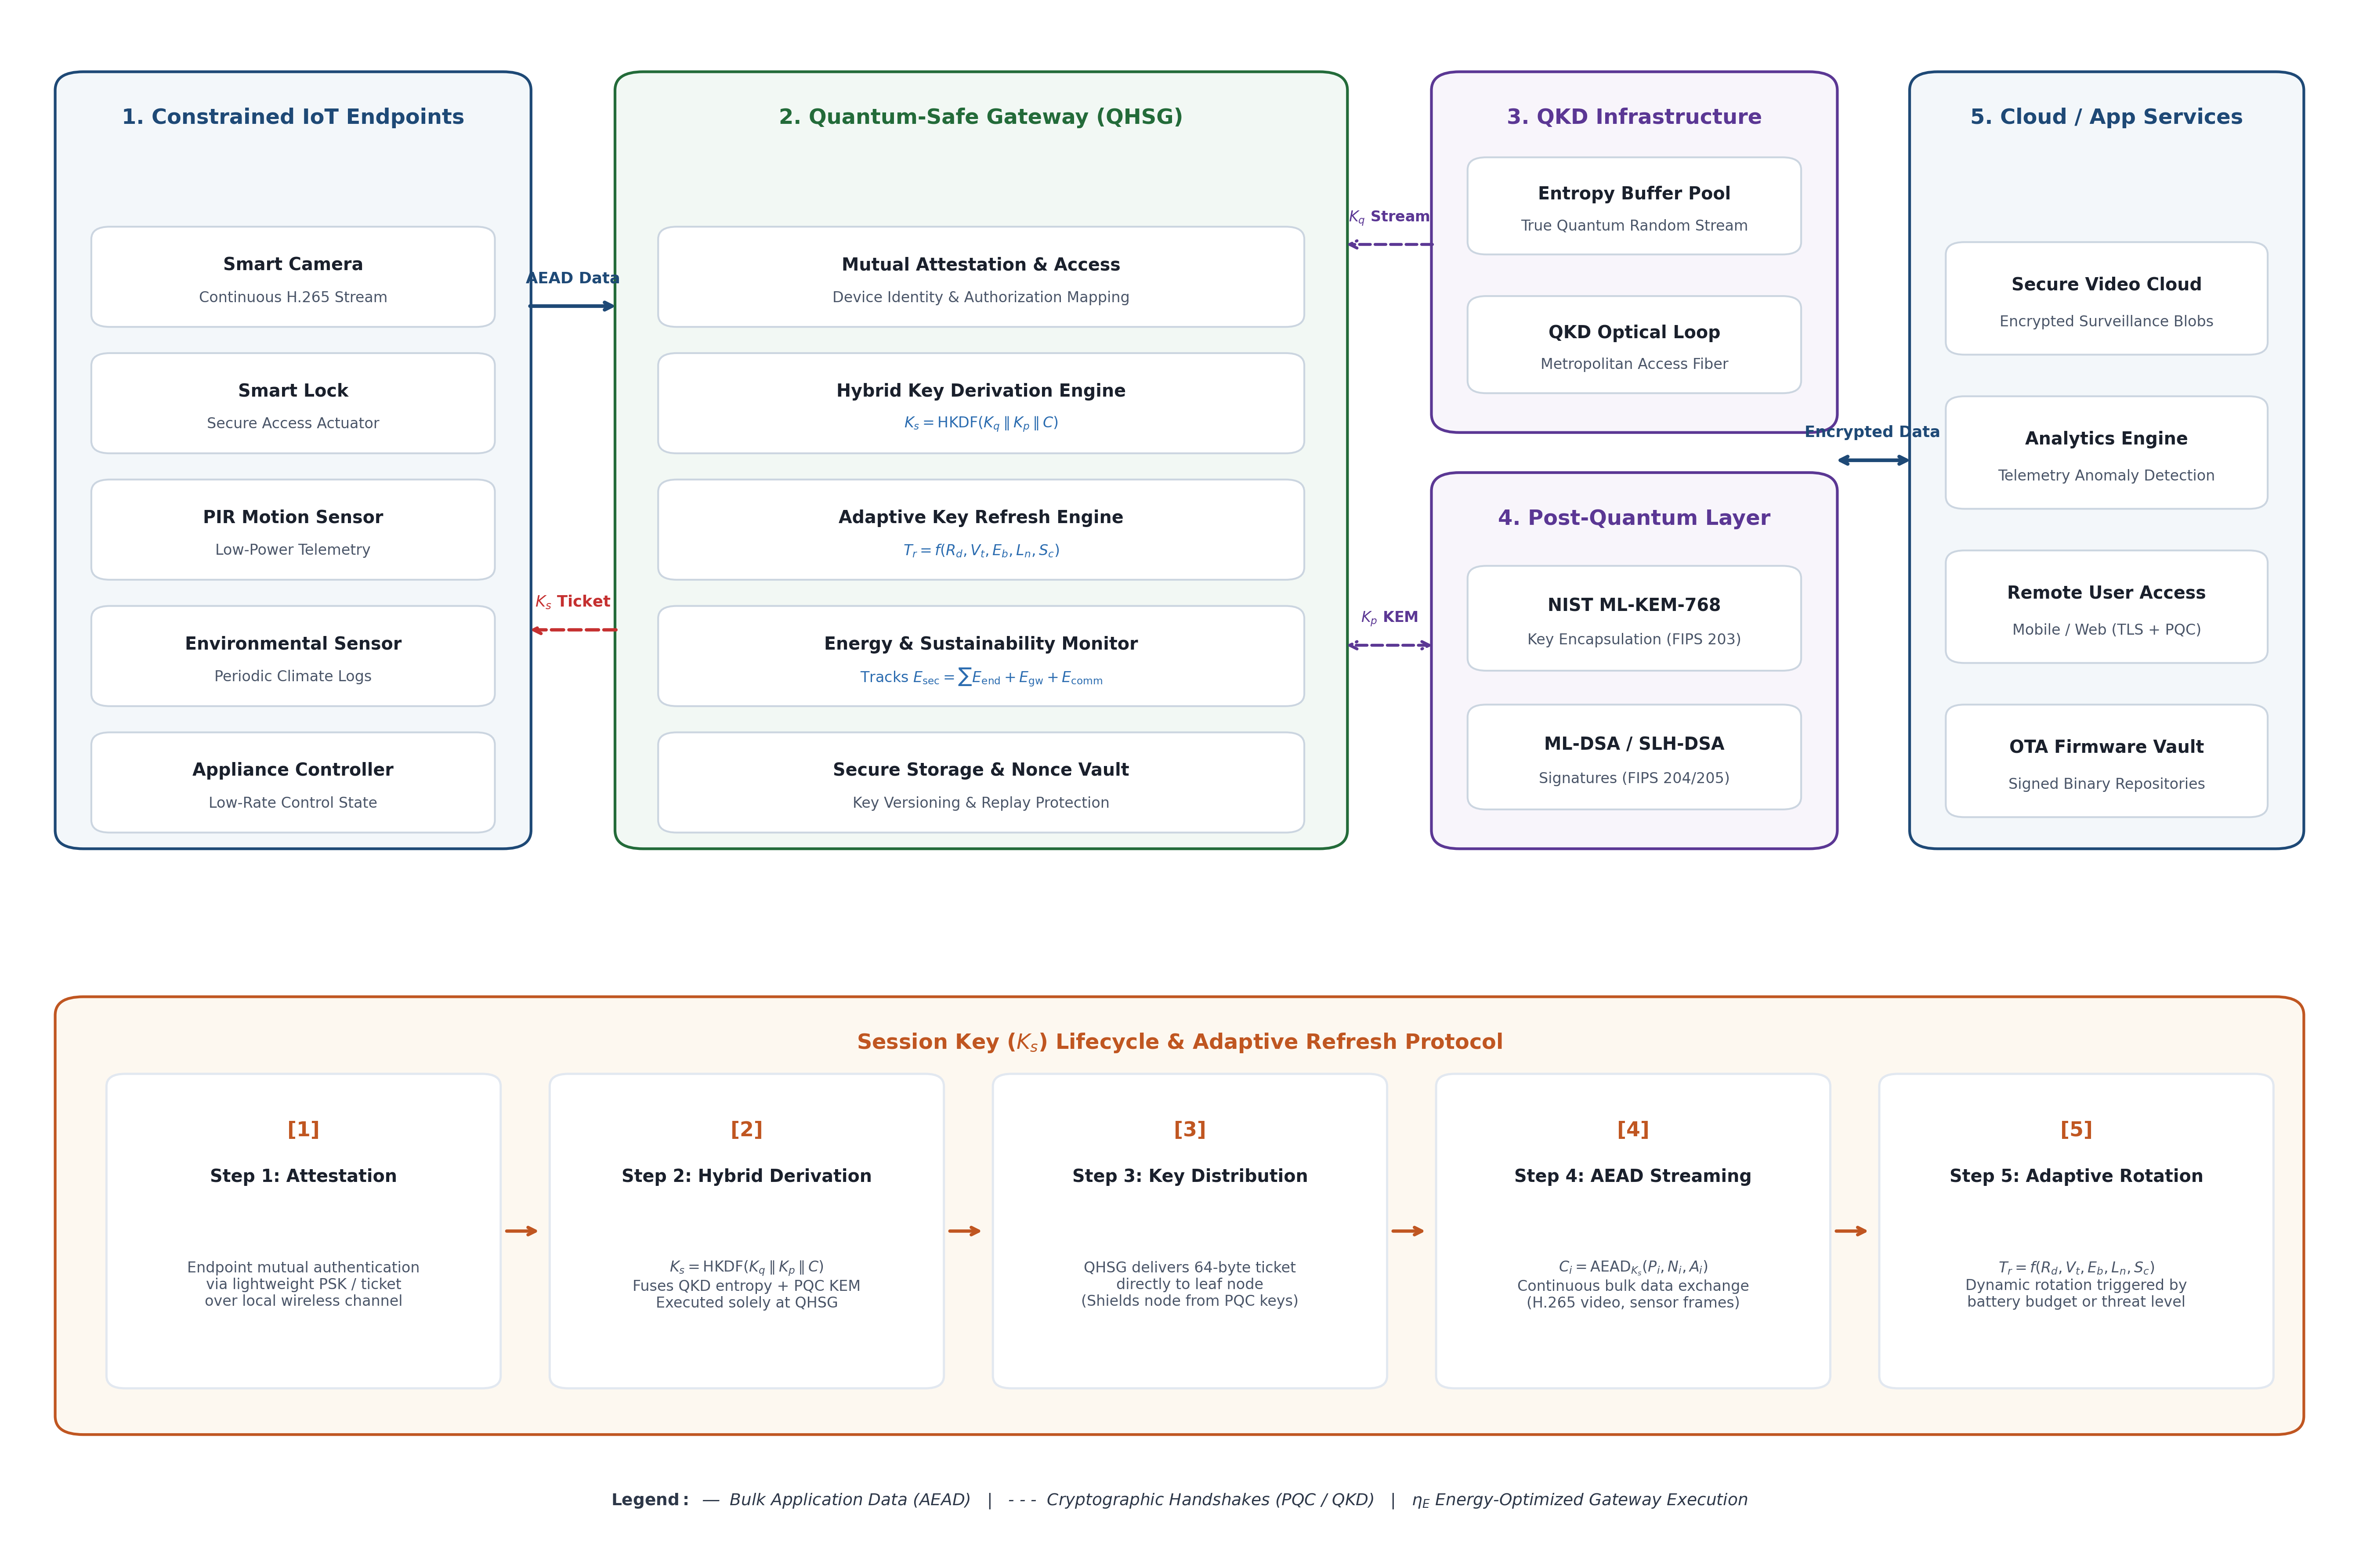

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# High resolution, generous widescreen canvas (Elsevier double-column standard)
fig, ax = plt.subplots(figsize=(18, 12), dpi=300)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.axis('off')

# Elsevier-grade academic color palette
c_blue_bg  = '#F3F7FA'; c_blue_bd  = '#1E4976'
c_grn_bg   = '#F2F8F4'; c_grn_bd   = '#236B39'
c_purp_bg  = '#F8F5FB'; c_purp_bd  = '#5B3794'
c_amb_bg   = '#FDF8F0'; c_amb_bd   = '#C05621'
c_box_wht  = '#FFFFFF'
c_text_main= '#1A202C'

def draw_panel(x, y, w, h, bg, bd, title, r=1.2, lw=1.5):
    rect = patches.FancyBboxPatch((x, y), w, h, boxstyle=f"round,pad=0.2,rounding_size={r}",
                                  facecolor=bg, edgecolor=bd, linewidth=lw)
    ax.add_patch(rect)
    if title:
        ax.text(x + w/2, y + h - 2.8, title, ha='center', va='center',
                fontsize=11.5, fontweight='bold', color=bd)

def draw_card(x, y, w, h, title, subtext="", bd=c_blue_bd, highlight=False):
    rect = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.15,rounding_size=0.8",
                                  facecolor=c_box_wht, edgecolor='#CBD5E0', linewidth=1.0)
    ax.add_patch(rect)
    if subtext:
        ax.text(x + w/2, y + h*0.62, title, ha='center', va='center',
                fontsize=9.5, fontweight='bold', color=c_text_main)
        ax.text(x + w/2, y + h*0.28, subtext, ha='center', va='center',
                fontsize=8.0, color='#2B6CB0' if highlight else '#4A5568')
    else:
        ax.text(x + w/2, y + h/2, title, ha='center', va='center',
                fontsize=9.5, fontweight='bold', color=c_text_main)

# =========================================================
# 1. UPPER DOMAINS (Y = 46 to 96)
# =========================================================

# 1. IoT Endpoints
draw_panel(2, 46, 20, 50, c_blue_bg, c_blue_bd, "1. Constrained IoT Endpoints")
devs = [
    ("Smart Camera", "Continuous H.265 Stream"),
    ("Smart Lock", "Secure Access Actuator"),
    ("PIR Motion Sensor", "Low-Power Telemetry"),
    ("Environmental Sensor", "Periodic Climate Logs"),
    ("Appliance Controller", "Low-Rate Control State")
]
y_d = 86
for name, sub in devs:
    draw_card(3.5, y_d - 6.2, 17, 6.2, name, sub)
    y_d -= 8.2

# 2. Quantum-Safe Home Gateway (QHSG)
draw_panel(26, 46, 31, 50, c_grn_bg, c_grn_bd, "2. Quantum-Safe Gateway (QHSG)")
gw_mods = [
    ("Mutual Attestation & Access", "Device Identity & Authorization Mapping", False),
    ("Hybrid Key Derivation Engine", r"$K_s = \mathrm{HKDF}(K_q \parallel K_p \parallel C)$", True),
    ("Adaptive Key Refresh Engine", r"$T_r = f(R_d, V_t, E_b, L_n, S_c)$", True),
    ("Energy & Sustainability Monitor", r"Tracks $E_{\mathrm{sec}} = \sum E_{\mathrm{end}} + E_{\mathrm{gw}} + E_{\mathrm{comm}}$", True),
    ("Secure Storage & Nonce Vault", "Key Versioning & Replay Protection", False)
]
y_g = 86
for name, sub, hl in gw_mods:
    draw_card(27.8, y_g - 6.2, 27.4, 6.2, name, sub, bd=c_grn_bd, highlight=hl)
    y_g -= 8.2

# 3. External Crypto Layers (QKD & PQC)
draw_panel(61, 73, 17, 23, c_purp_bg, c_purp_bd, "3. QKD Infrastructure")
draw_card(62.5, 84.5, 14, 6.0, "Entropy Buffer Pool", "True Quantum Random Stream", bd=c_purp_bd)
draw_card(62.5, 75.5, 14, 6.0, "QKD Optical Loop", "Metropolitan Access Fiber", bd=c_purp_bd)

draw_panel(61, 46, 17, 24, c_purp_bg, c_purp_bd, "4. Post-Quantum Layer")
draw_card(62.5, 57.5, 14, 6.5, "NIST ML-KEM-768", "Key Encapsulation (FIPS 203)", bd=c_purp_bd)
draw_card(62.5, 48.5, 14, 6.5, "ML-DSA / SLH-DSA", "Signatures (FIPS 204/205)", bd=c_purp_bd)

# 4. Cloud Application Services
draw_panel(81.5, 46, 16.5, 50, c_blue_bg, c_blue_bd, "5. Cloud / App Services")
cloud_apps = [
    ("Secure Video Cloud", "Encrypted Surveillance Blobs"),
    ("Analytics Engine", "Telemetry Anomaly Detection"),
    ("Remote User Access", "Mobile / Web (TLS + PQC)"),
    ("OTA Firmware Vault", "Signed Binary Repositories")
]
y_c = 85
for name, sub in cloud_apps:
    draw_card(83, y_c - 7.0, 13.5, 7.0, name, sub)
    y_c -= 10.0

# Connectors Upper
ax.annotate("", xy=(26, 81), xytext=(22, 81), arrowprops=dict(arrowstyle="->", color=c_blue_bd, lw=2))
ax.text(24, 82.5, "AEAD Data", ha='center', fontsize=8.5, fontweight='bold', color=c_blue_bd)

ax.annotate("", xy=(22, 60), xytext=(26, 60), arrowprops=dict(arrowstyle="->", color='#C53030', lw=1.8, ls='--'))
ax.text(24, 61.5, "$K_s$ Ticket", ha='center', fontsize=8.5, fontweight='bold', color='#C53030')

ax.annotate("", xy=(57, 85), xytext=(61, 85), arrowprops=dict(arrowstyle="->", color=c_purp_bd, lw=1.6, ls='--'))
ax.text(59, 86.5, "$K_q$ Stream", ha='center', fontsize=8.0, fontweight='bold', color=c_purp_bd)

ax.annotate("", xy=(57, 59), xytext=(61, 59), arrowprops=dict(arrowstyle="<->", color=c_purp_bd, lw=1.6, ls='--'))
ax.text(59, 60.5, "$K_p$ KEM", ha='center', fontsize=8.0, fontweight='bold', color=c_purp_bd)

ax.annotate("", xy=(81.5, 71), xytext=(78, 71), arrowprops=dict(arrowstyle="<->", color=c_blue_bd, lw=2))
ax.text(79.7, 72.5, "Encrypted Data", ha='center', fontsize=8.5, fontweight='bold', color=c_blue_bd)

# =========================================================
# 2. LOWER WORKFLOW: SESSION KEY LIFECYCLE (Y = 8 to 36)
# =========================================================
draw_panel(2, 8, 96, 28, c_amb_bg, c_amb_bd, "Session Key ($K_s$) Lifecycle & Adaptive Refresh Protocol")

steps = [
    ("Step 1: Attestation", "Endpoint mutual authentication\nvia lightweight PSK / ticket\nover local wireless channel"),
    ("Step 2: Hybrid Derivation", r"$K_s = \mathrm{HKDF}(K_q \parallel K_p \parallel C)$" + "\nFuses QKD entropy + PQC KEM\nExecuted solely at QHSG"),
    ("Step 3: Key Distribution", "QHSG delivers 64-byte ticket\ndirectly to leaf node\n(Shields node from PQC keys)"),
    ("Step 4: AEAD Streaming", r"$C_i = \mathrm{AEAD}_{K_s}(P_i, N_i, A_i)$" + "\nContinuous bulk data exchange\n(H.265 video, sensor frames)"),
    ("Step 5: Adaptive Rotation", r"$T_r = f(R_d, V_t, E_b, L_n, S_c)$" + "\nDynamic rotation triggered by\nbattery budget or threat level")
]

x_s = 4.2
for i, (title, sub) in enumerate(steps):
    rect = patches.FancyBboxPatch((x_s, 11), 16.5, 20, boxstyle="round,pad=0.2,rounding_size=0.8",
                                  facecolor=c_box_wht, edgecolor='#E2E8F0', linewidth=1.2)
    ax.add_patch(rect)
    ax.text(x_s + 8.25, 27.5, f"[{i+1}]", ha='center', va='center', fontsize=11, fontweight='bold', color=c_amb_bd)
    ax.text(x_s + 8.25, 24.5, title, ha='center', va='center', fontsize=9.5, fontweight='bold', color=c_text_main)
    ax.text(x_s + 8.25, 17.5, sub, ha='center', va='center', fontsize=8.0, color='#4A5568')
    if i < 4:
        ax.annotate("", xy=(x_s + 18.5, 21), xytext=(x_s + 16.8, 21),
                    arrowprops=dict(arrowstyle="->", color=c_amb_bd, lw=1.8))
    x_s += 19.0

# Legend
ax.text(50, 3.5,
        r"$\mathbf{Legend:}$  ―  Bulk Application Data (AEAD)   |   - - -  Cryptographic Handshakes (PQC / QKD)   |   $\eta_E$ Energy-Optimized Gateway Execution",
        ha='center', va='center', fontsize=9.0, color='#2D3748', style='italic')

plt.tight_layout()
plt.savefig("Fig1.png", dpi=300, bbox_inches='tight')
plt.savefig("Fig1.pdf", bbox_inches='tight')
print("Successfully generated Fig1.png and Fig1.pdf with high resolution and clear margins!")
if IN_COLAB:
    files.download("Fig1.png")
    files.download("Fig1.pdf")